In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
df = yf.download('AAPL', start='2018-01-01', end='2024-01-01')
prices = df['Close']['AAPL']
prices.to_csv('../data/aapl_prices.csv')
print(prices.head())
print(prices.shape)

[*********************100%***********************]  1 of 1 completed

Date
2018-01-02    40.267090
2018-01-03    40.260063
2018-01-04    40.447067
2018-01-05    40.907558
2018-01-08    40.755638
Name: AAPL, dtype: float64
(1509,)


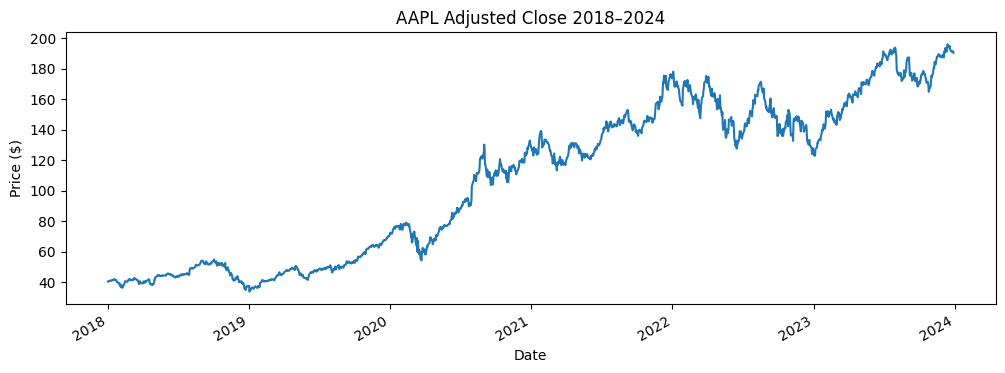

In [22]:
prices.plot(figsize=(12, 4), title='AAPL Adjusted Close 2018–2024')
plt.ylabel('Price ($)')
plt.show()

In [23]:
returns = np.log(prices / prices.shift(1)).dropna()
target = returns.shift(-1).dropna()
returns = returns[returns.index.isin(target.index)]
print(returns.shape, target.shape)

(1507,) (1507,)


In [24]:
print(f"Returns shape: {returns.shape}")
print(f"Target shape: {target.shape}")
print(f"Any NaN in returns: {returns.isna().any()}")
print(f"Any NaN in target: {target.isna().any()}")
print(f"\nFirst 5 returns:\n{returns.head()}")
print(f"\nFirst 5 targets:\n{target.head()}")

Returns shape: (1507,)
Target shape: (1507,)
Any NaN in returns: False
Any NaN in target: False

First 5 returns:
Date
2018-01-03   -0.000175
2018-01-04    0.004634
2018-01-05    0.011321
2018-01-08   -0.003721
2018-01-09   -0.000115
Name: AAPL, dtype: float64

First 5 targets:
Date
2018-01-03    0.004634
2018-01-04    0.011321
2018-01-05   -0.003721
2018-01-08   -0.000115
2018-01-09   -0.000229
Name: AAPL, dtype: float64


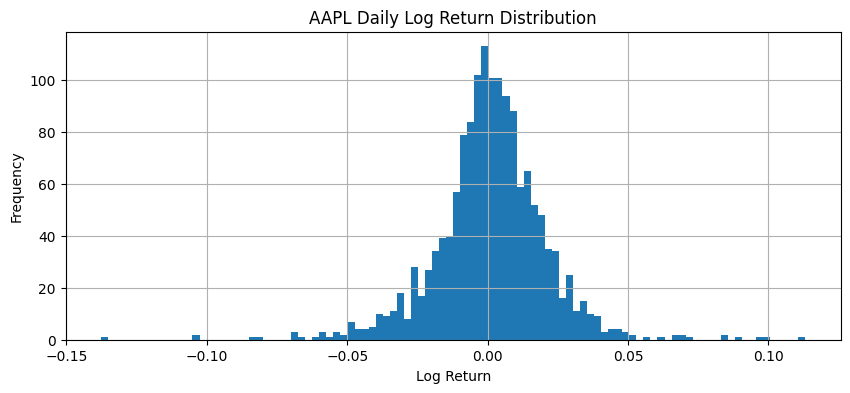

In [25]:
returns.hist(bins=100, figsize=(10, 4))
plt.title('AAPL Daily Log Return Distribution')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.show()

In [26]:
features = pd.DataFrame(index=prices.index)
sma5  = prices.rolling(5).mean()
sma20 = prices.rolling(20).mean()
sma50 = prices.rolling(50).mean()
ema12 = prices.ewm(span=12).mean()
ema26 = prices.ewm(span=26).mean()
price_vs_sma20 = (prices / sma20) - 1
sma_crossover  = (sma5 > sma20).astype(int)
macd           = ema12 - ema26
macd_signal    = macd.ewm(span=9).mean()
features['sma5']           = sma5
features['sma20']          = sma20
features['sma50']          = sma50
features['ema12']          = ema12
features['ema26']          = ema26
features['price_vs_sma20'] = price_vs_sma20
features['sma_crossover']  = sma_crossover
features['macd']           = macd
features['macd_signal']    = macd_signal
print(features.shape)
print(features.head(10))

(1509, 9)
                 sma5  sma20  sma50      ema12      ema26  price_vs_sma20  \
Date                                                                        
2018-01-02        NaN    NaN    NaN  40.267090  40.267090             NaN   
2018-01-03        NaN    NaN    NaN  40.263284  40.263441             NaN   
2018-01-04        NaN    NaN    NaN  40.335014  40.329416             NaN   
2018-01-05        NaN    NaN    NaN  40.515744  40.491040             NaN   
2018-01-08  40.527483    NaN    NaN  40.580923  40.552401             NaN   
2018-01-09  40.624255    NaN    NaN  40.622248  40.592169             NaN   
2018-01-10  40.720564    NaN    NaN  40.648882  40.618745             NaN   
2018-01-11  40.825755    NaN    NaN  40.716526  40.675829             NaN   
2018-01-12  40.923466    NaN    NaN  40.850972  40.782590             NaN   
2018-01-16  41.009488    NaN    NaN  40.914412  40.838222             NaN   

            sma_crossover      macd  macd_signal  
Date          

In [27]:
print(f"First 5 rows of sma50 (should be NaN):\n{sma50.head()}")
print(f"\nFirst non-NaN row of sma50: {sma50.first_valid_index()}")
print(f"\nNaN counts per feature:\n{features.isna().sum()}")

First 5 rows of sma50 (should be NaN):
Date
2018-01-02   NaN
2018-01-03   NaN
2018-01-04   NaN
2018-01-05   NaN
2018-01-08   NaN
Name: AAPL, dtype: float64

First non-NaN row of sma50: 2018-03-14 00:00:00

NaN counts per feature:
sma5               4
sma20             19
sma50             49
ema12              0
ema26              0
price_vs_sma20    19
sma_crossover      0
macd               0
macd_signal        0
dtype: int64


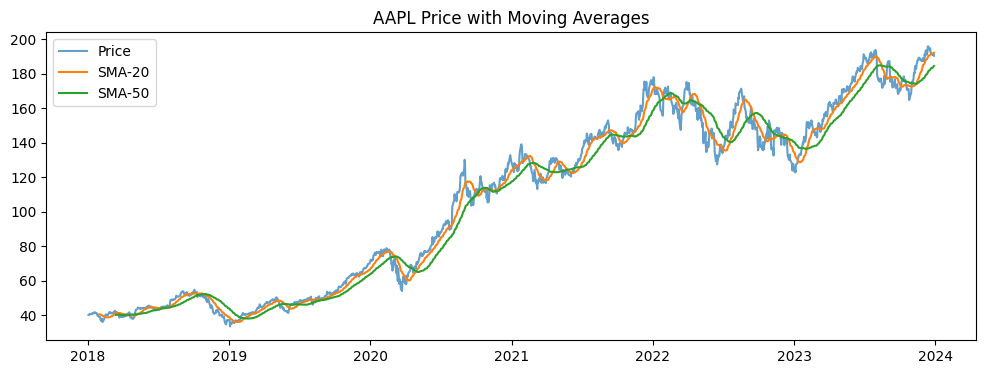

In [28]:
plt.figure(figsize=(12, 4))
plt.plot(prices, label='Price', alpha=0.7)
plt.plot(sma20, label='SMA-20')
plt.plot(sma50, label='SMA-50')
plt.title('AAPL Price with Moving Averages')
plt.legend()
plt.show()

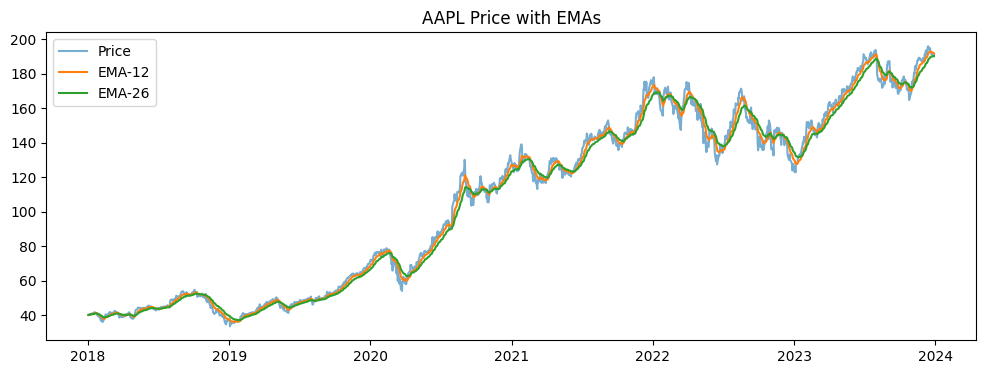

In [29]:
plt.figure(figsize=(12, 4))
plt.plot(prices, label='Price', alpha=0.6)
plt.plot(ema12, label='EMA-12')
plt.plot(ema26, label='EMA-26')
plt.title('AAPL Price with EMAs')
plt.legend()
plt.show()